In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Introduction to scikit-learn

Scikit-learn is a popular Python library used in machine learning (ML). It provides a framework and functions that are commonly used to pre-process the data, build a model, evaluate it and set its hyperparameters, etc. Mastering this library will help to quickly implement workflows to process data (at a relatively small scale). 

The goal of this tutorial is to show the basics of data processing with scikit-learn (sklearn). We will focus on simple ML tasks with elementary techniques, such as linear regression with polynomial features (polynomial regression).

## Generate a simple regression dataset ($\sin$ function)

We generate a simple regression dataset: one explanatory variable $X$ and one response variable $Y$. The data points $(X_i, Y_i)$ are generated in the following way:
$$
X_i \sim \mathcal{U}(-x_{\min}, x_{\max}), \quad
Y_i = \sin(X_i) + \epsilon_i , \quad 
\text{with } \epsilon_i \sim \mathcal{N}(0, \sigma^2),
$$
where the $X_i$ are independently sampled, as well as the $\epsilon_i$. We generate a dataset of size $n$.

**Question 1**

With NumPy: Generate a dataset of size $n = 25$ with $\sigma = 0.1$, $x_{\min} = -\pi$ and $x_{\min} = \pi$.
The dataset will be put in the form of two `np.array` of size `n`, denoted by `x` and `y`, such that `x[i]` $= X_i$ and `y[i]` $= Y_i$. One can use `np.random.uniform` and `np.random.normal`.

With matplotlib: plot the generated data points $(X_i, Y_i)$. One can use `plt.scatter`.

In [2]:
#rng = np.random.RandomState(1234)
xmin, xmax = -np.pi, np.pi

n = 25
x = np.random.uniform(xmin, xmax, n)

sigma = .1
y = np.sin(x) + np.random.normal(scale = sigma, size = n)

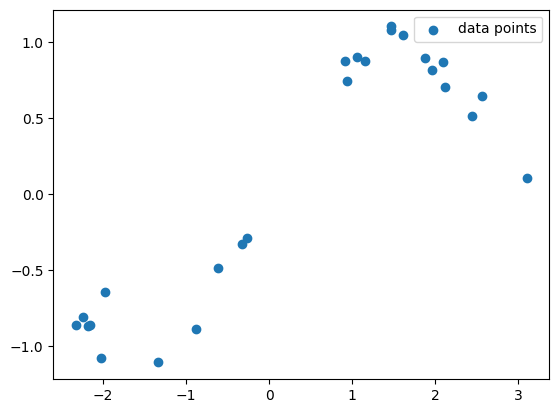

In [3]:
plt.scatter(x, y, label = "data points")
plt.legend()
plt.show()

## Polynomial regression with NumPy

Before using the tools provided by scikit-learn, we will perform a polynomial regression of $Y$ on $X$ with NumPy only. By doing so, we will be able to check that the sklearn functions implement the tools we want.

**Question 2**

With NumPy: build the matrix of polynomial features of $X$ with maximal degree $p = 3$. The matrix of features will be denoted by `X`. Then, perform the linear regression of `y` on `X` and compute its coefficients. One can use `np.vander` to compute the polynomial features.

With matplotlib: plot the regression curve and the data points on the same figure.

In [4]:
p = 3

X = np.vander(x, p + 1, increasing = True)
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print(beta)

[-0.02751141  0.85805516  0.00832489 -0.09457593]


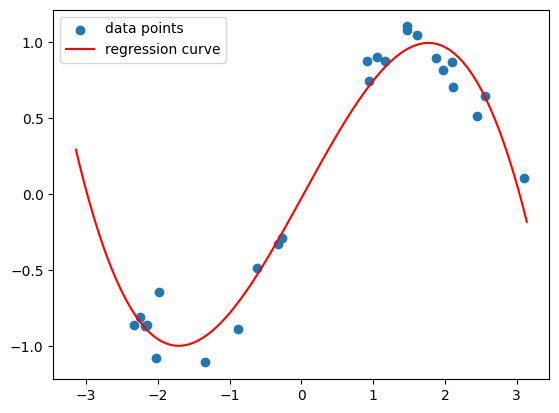

In [5]:
# Building the regression curve
npoints = 100   # number of points used to plot it
reg_x = np.linspace(xmin, xmax, npoints)    # x-axis

reg_X = np.vander(reg_x, p + 1, increasing = True)
reg_y = reg_X @ beta    # y-axis

# Plot
plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.legend()
plt.show()

## Polynomial regression with sklearn (1)

Now, we will use the tools provided by sklearn to perform the same regression. Building the polynomial features is a *preprocessing* method: it performs a transformation of the dataset to improve the performance of the method that will be used subsequently. In our case, this method is a simple linear regression.

We will use `sklearn.preprocessing.PolynomialFeatures` to generate the polynomial features and `sklearn.linear_model.LinearRegression` to perform the linear regression.

**Question 3**

With sklearn: import the relevant classes, build `X`, then perform the polynomial regression with degree $p = 3$. One can use the method `fit_transform` of `PolynomialFeatures` and `fit` of `LinearRegression`. Note: one can convert `x` to a 2D array with $n$ rows and 1 column with `np.expand_dims`.

Print: 
 * the coefficients of the regression;
 * the $R^2$ determination coefficient;
 * the Residual Sum of Squares (RSS) of the fitted model on the dataset.

Plot the regression curve and the data points. One can use the method `predict` of `LinearRegression`.

Check that the coefficients of the regression are the same as computed previously with NumPy.

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [7]:
p = 3

polfeat = PolynomialFeatures(degree = p) 
# Note: PolynomialFeatures requires that the input dataset is a 2D array,
#       so we have to reshape x with np.expand_dims.
X = polfeat.fit_transform(np.expand_dims(x, 1))

In [8]:
linreg = LinearRegression()
linreg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
print("coeffs = ", linreg.coef_)
print("R2 = ", linreg.score(X, y))
print("RSS = ", ((linreg.predict(X) - y)**2).sum())

coeffs =  [ 0.          0.85805516  0.00832489 -0.09457593]
R2 =  0.9710169882794017
RSS =  0.4729451286324557


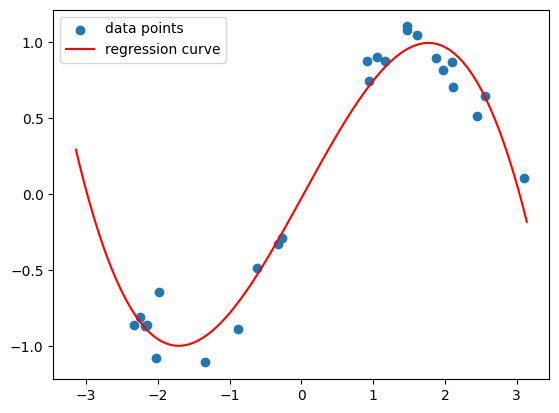

In [10]:
npoints = 100

reg_x = np.linspace(xmin, xmax, npoints)
reg_X = polfeat.fit_transform(np.expand_dims(reg_x, 1))
reg_y = linreg.predict(reg_X)

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.legend()
plt.show()

## Polynomial regression with sklearn (2): pipelines

To automate the entire data processing and wrap all its stages, we will use the `sklearn.pipeline.Pipeline` class. This class is very handy to perform all the stages of data processing in one line, which is useful in many contexts (hyperparameter search, testing the model on new data, replace a stage by another...).

**Question 4**

Build a pipeline with two stages: 
 1. building the polynomial features with `PolynomialFeatures`;
 2. performing the linear regression with `LinearRegression`.

Then, use it to perform the polynomial regression.

Print the coefficients of the linear regression by using the name it was given when constructing the pipeline.

Plot the regression curve and the data points (with `predict`).

In [11]:
from sklearn.pipeline import Pipeline

In [12]:
p = 3

polfeat = PolynomialFeatures(degree = p)
linreg = LinearRegression()

pipeline = Pipeline([("PolynomialFeatures", polfeat),
                    ("LinearRegression", linreg)])

In [13]:
pipeline.fit(np.expand_dims(x, 1), y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('PolynomialFeatures', ...), ('LinearRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [14]:
pipeline["LinearRegression"].coef_

array([ 0.        ,  0.85805516,  0.00832489, -0.09457593])

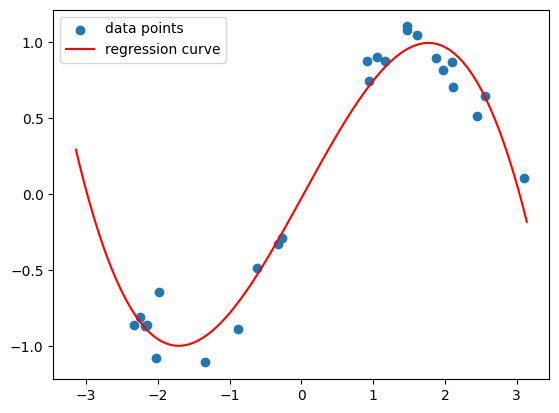

In [15]:
npoints = 100

reg_x = np.linspace(xmin, xmax, npoints)
reg_y = pipeline.predict(np.expand_dims(reg_x, 1))

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.legend()
plt.show()

## Polynomial regression with sklearn (3): pipelines with custom transformations

Our pipeline is not complete: we still have to transform the array of inputs `x` into a 2D array with one column before sending it to the pipeline. To have a fully functional pipeline, we will add a transformation of the data at the first stage, to convert it from a 1D array to a 2D array.

We will use `sklearn.preprocessing.FunctionTransformer`.

**Question 5**

Write a function `f` transforming a 1D input into a 2D input and put it into a `FunctionTransformer`.

Build a new pipeline based on the previous one, but with a first stage performing the function `f`.

Perform the polynomial regression.

In [16]:
from sklearn.preprocessing import FunctionTransformer

In [17]:
transform = FunctionTransformer(lambda t: np.expand_dims(t, 1))

p = 3
polfeat = PolynomialFeatures(degree = p)

linreg = LinearRegression()

pipeline = Pipeline([("Transfo", transform),
                    ("PolynomialFeatures", polfeat),
                    ("LinearRegression", linreg)])

In [18]:
pipeline.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Transfo', ...), ('PolynomialFeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...x7f7a19fc4a40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argum

In [19]:
pipeline["LinearRegression"].coef_

array([ 0.        ,  0.85805516,  0.00832489, -0.09457593])

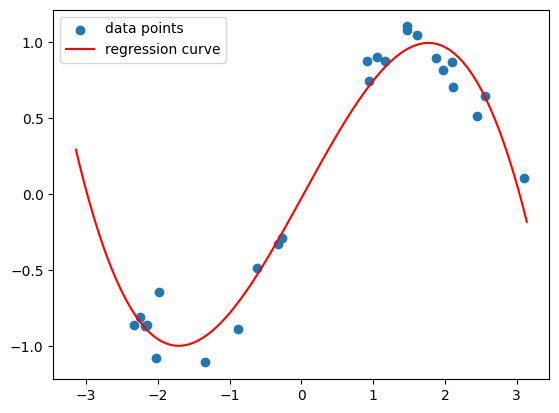

In [20]:
npoints = 100

reg_x = np.linspace(xmin, xmax, npoints)
reg_y = pipeline.predict(reg_x)

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.legend()
plt.show()

## Sandbox: linear regression with custom features

We have previously performed linear regressions with polynomial features by using the `PolynomialFeatures` preprocessing class. But it is also possible to use `FunctionTransformer` to build custom features (and not only polynomial ones). For instance, instead of computing $(1, x, x^2, x^3, \cdots)$ for each input $x$, one can compute $(1, x, \exp(x), \sqrt[3]{x}, \cdots)$, and then perform a linear regression.

**Question 6 (optional)**

Write a function that builds features based on custom functions. Put it into a pipeline and perform the linear regression on these features.

In [21]:
def func_transform(t):
    funcs = [lambda z: np.ones(t.shape[0]), 
             lambda z: z, 
             np.exp,
             lambda z: np.sign(z) * np.abs(z)**(1/3)]
    return np.stack([f(t) for f in funcs], axis = 1)

In [22]:
transform = FunctionTransformer(func_transform)

linreg = LinearRegression()

pipeline = Pipeline([("Transfo", transform),
                    ("LinearRegression", linreg)])

In [23]:
pipeline.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Transfo', ...), ('LinearRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fun...x7f7a19fc58a0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to

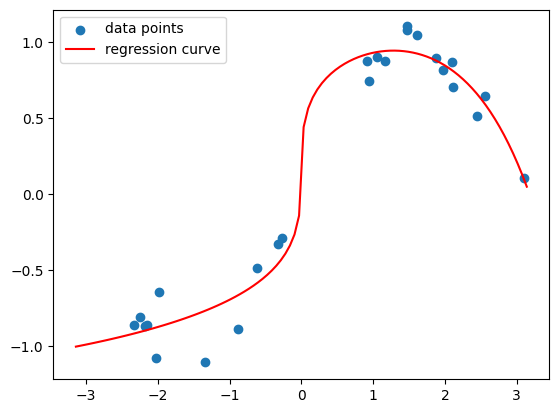

In [24]:
npoints = 100
reg_x = np.linspace(xmin, xmax, npoints)

reg_y = pipeline.predict(reg_x)

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.legend()
plt.show()

# Underfitting and overfitting

We introduce here several concepts that are fundamental in ML: 
 * underfitting and overfitting;
 * training, validation and test datasets;
 * training, validation and test losses.

Even with the simple example of polynomial regression, it is possible to identify several issues related to the number of data points, the number of features and the difficulty of the task. These issues can be classified as *underfitting* or *overfitting*. One way to solve some of them is to split the dataset into several parts, each with its purpose.

## Generate the dataset

We generate a simple regression dataset: one explanatory variable $X$, and one explicative variable $Y$. the data points $(X_i, Y_i)$ are generated in the following way:
$$
X_i \sim \mathcal{U}(-x_{\min}, x_{\max}), \quad
Y_i = \sin(X_i) + \epsilon_i , \quad 
\text{with } \epsilon_i \sim \mathcal{N}(0, \sigma^2),
$$
where the $X_i$ are independently sampled, as well as the $\epsilon_i$. We generate a dataset of size $n$.

**Question 1**

With NumPy: Generate a dataset of size $n = 25$ with $\sigma = 0.2$, $x_{\min} = -2\pi$ and $x_{\min} = 2\pi$.

In [25]:
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [26]:
#rng = np.random.RandomState(1234)
xmin, xmax = -2*np.pi, 2*np.pi

n = 25
x = np.random.uniform(xmin, xmax, n)

sigma = .2
y = np.sin(x) + np.random.normal(scale = sigma, size = n)

## Underfitting

**Question 2**

Perform a poynomial regression with degree $p = 3$.

Plot the regression curve, the dataset and the sine curve (which is the ground truth). 

What do we observe? Is our model good?

In [27]:
transform = FunctionTransformer(lambda t: np.expand_dims(t, 1))

p = 3
polfeat = PolynomialFeatures(degree = p)

linreg = LinearRegression()

pipeline = Pipeline([("Transfo", transform),
                    ("PolynomialFeatures", polfeat),
                    ("LinearRegression", linreg)])

pipeline.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Transfo', ...), ('PolynomialFeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...x7f7a1a01cae0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argum

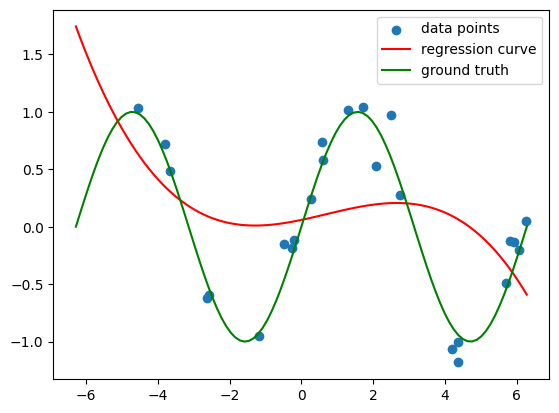

In [28]:
npoints = 100
reg_x = np.linspace(xmin, xmax, npoints)

reg_y = pipeline.predict(reg_x)

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.plot(reg_x, np.sin(reg_x), c = "green", label = "ground truth")
plt.legend()
plt.show()

Since we want the make the regression of data points that have been generated on two periods of the $\sin$ function with a polynomial of degree 3, it is impossible to fit correctly the data. This lack of fit, between the data points and the model, is called *underfitting*.

## Correct fit

To improve the quality of our model, we will increase the maximum degree of the polynomial used to generate the polynomial features. We will take $p = 5$.

With sklearn, it is not necessary to build a new pipeline to make an hyperparameter change like this. One can get the dictionary of hyperparameters with the method `get_params` of `Pipeline`, and change one of these by using the method `set_params`.

**Question 3**

Print the dictionary of all hyperparameters of the previously used pipeline.

Then, change the maximal degree of the polynomial from $3$ to $5$, fit the model again, and plot the new regression curve.

Note: the `set_params` method returns the `Pipeline` object with the new params.

In [29]:
# Look at the hyperparameters of the model

pipeline.get_params()

{'memory': None,
 'steps': [('Transfo',
   FunctionTransformer(func=<function <lambda> at 0x7f7a1a01cae0>)),
  ('PolynomialFeatures', PolynomialFeatures(degree=3)),
  ('LinearRegression', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'Transfo': FunctionTransformer(func=<function <lambda> at 0x7f7a1a01cae0>),
 'PolynomialFeatures': PolynomialFeatures(degree=3),
 'LinearRegression': LinearRegression(),
 'Transfo__accept_sparse': False,
 'Transfo__check_inverse': True,
 'Transfo__feature_names_out': None,
 'Transfo__func': <function __main__.<lambda>(t)>,
 'Transfo__inv_kw_args': None,
 'Transfo__inverse_func': None,
 'Transfo__kw_args': None,
 'Transfo__validate': False,
 'PolynomialFeatures__degree': 3,
 'PolynomialFeatures__include_bias': True,
 'PolynomialFeatures__interaction_only': False,
 'PolynomialFeatures__order': 'C',
 'LinearRegression__copy_X': True,
 'LinearRegression__fit_intercept': True,
 'LinearRegression__n_jobs': None,
 'LinearRegression__positive

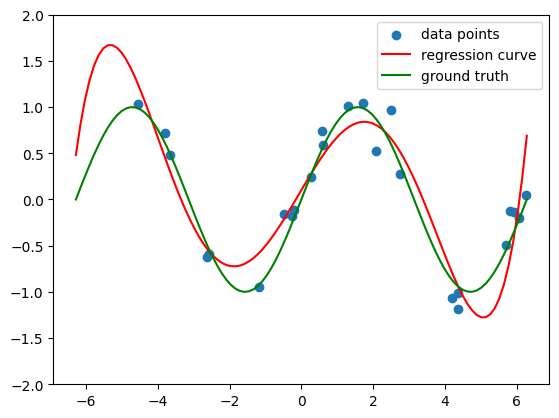

In [30]:
p = 5

pipeline.set_params(PolynomialFeatures__degree = p).fit(x, y)

npoints = 100
reg_x = np.linspace(xmin, xmax, npoints)

reg_y = pipeline.predict(reg_x)

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.plot(reg_x, np.sin(reg_x), c = "green", label = "ground truth")
plt.ylim(-2, 2)
plt.legend()
plt.show()

By increasing the number of features (and thus, the number of parameters in the linear regression), it is possible to obtain a better fit of the data.

## Overfitting

However, increasing the number of features and the number of parameters to tune is not free. First, the computational cost is slightly higher (but it is negligible for such simple datasets and ML methods). Second, we may end *overfitting* the datset, which we illustrate below.

**Question 4**

Perform the polynomial regression with maximal degree $p = 15$.

Plot the regression curve, the dataset and the sine curve.

Is our model good?

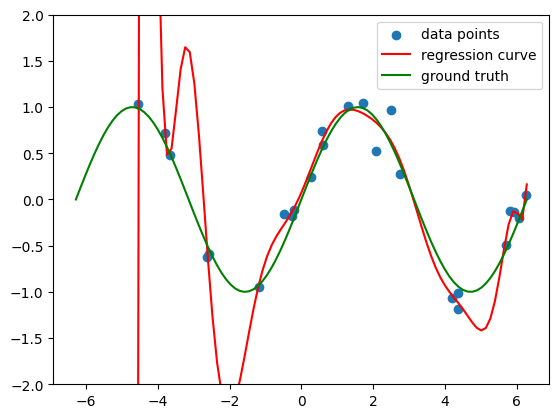

In [31]:
p = 15

pipeline.set_params(PolynomialFeatures__degree = p).fit(x, y)

npoints = 100

reg_x = np.linspace(xmin, xmax, npoints)
reg_y = pipeline.predict(reg_x)

plt.scatter(x, y, label = "data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.plot(reg_x, np.sin(reg_x), c = "green", label = "ground truth")
plt.ylim(-2, 2)
plt.legend()
plt.show()

Is our model good? It depends:
 * if we are interested only in the quality of the regression at the points of the dataset, the model is quite good: the regression curve passes through all the points of the dataset;
 * if we are interested in the "distance" between the regression curve and the *ground truth* curve, the model if very bad in some areas: the regression curve can be very far from the ground truth.

We observe the phenomenon of *overfitting*: the regression curve passes through all the data points used for the regression, but is very bad in some areas. Usually, we want the model to be good, not only at the points that have observed in the dataset, but also at new points that have not been observed yet: we want the model to *generalize* well.

## Datasets: training/validation/test

To evaluate the ability of model to generalize, we use, not 1, but 3 datasets: the training dataset, the validation dataset, and the test dataset:
 * the *training dataset* is the one that we use to fit the parameters of the model;
 * the *validation dataset* is used only to evaluate the ability of a given model to generalize (the data points it contains are not used to fit the model); usually, it is used on the various models (trained with the training set) the practitioner wants to test, as long as the final model has not been selected;
 * once the final model has been selected, we compute its performance over the *test dataset*, which is used only at the end of the search.

**Question 5**

Write a function generating a dataset (exactly the same way as `x` and `y` have been generated). This function will take arguments $n$ (the number of data points to generate), $x_{\min}$, $x_{\max}$ and $\sigma$, and return a pair $(X, Y)$. 

Optional: add the optional argument `rng` to guarantee reproducibility. The `rng` argument is an instance of `np.random.RandomState`, which is the NumPy class for Random Number Generators (RNG). For example, by creating a RNG object with `rng = np.random.RandomState(some_integer)`, we ensure that the objects "randomly generated" with `rng.normal` or `rng.uniform` would always be the same (which is not the case with `np.random.normal` and `np.random.uniform`).

With $x_{\min} = -2\pi$, $x_{\max} = 2 \pi$ and $\sigma = 0.2$, generate three different datasets (training, validation, test), each of size $n = 25$.

In [32]:
def generate_data(n, xmin, xmax, sigma, rng = None):
    if rng is None:
        x = np.random.uniform(xmin, xmax, n)
        y = np.sin(x) + np.random.normal(scale = sigma, size = n)
    else:
        x = rng.uniform(xmin, xmax, n)
        y = np.sin(x) + rng.normal(scale = sigma, size = n)
    return x, y

In [33]:
# Note for the correction: we can use a random number generator to ensure reproducibility
rng = np.random.RandomState(1234)
#rng = None

xmin, xmax = -2*np.pi, 2*np.pi
sigma = .2

n_train = 25
n_valid = 25
n_test = 25

x_train, y_train = generate_data(n_train, xmin, xmax, sigma, rng)
x_valid, y_valid = generate_data(n_valid, xmin, xmax, sigma, rng)
x_test, y_test = generate_data(n_test, xmin, xmax, sigma, rng)

**Question 6**

Write a function that computes the Mean Square Error (MSE) loss, given a model, an input $X$, and a target $Y$. The MSE loss writes:
$$
\mathrm{MSE}(\hat{Y}, Y) = \frac{1}{n} \sum_{i = 1}^n (\hat{Y}_i - Y_i)^2,
\qquad \text{where: } \hat{Y}_i = \mathrm{model}(X_i) .
$$

Note: the loss computed on the training set is the *training loss*, the loss computed on the validation set is the *validation loss*, and the loss computed on the test set is the *test loss*.

With $p = 15$, perform a polynomial regression on the training set. Then, compute the MSE of the resulting model on the training set and the validation set. What do we observe?

In [34]:
def compute_loss(model, x, y):
    return ((model.predict(x) - y)**2).mean()

0.027457929366116015
2346.2742491366103


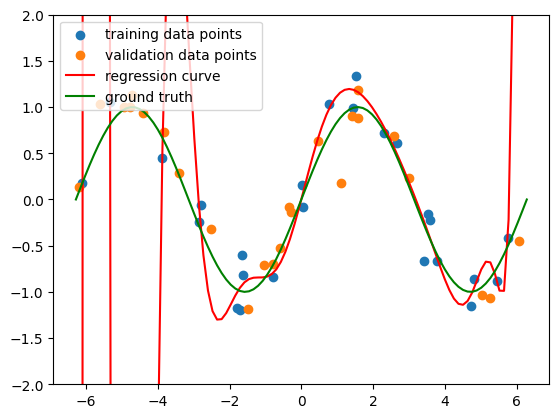

In [35]:
p = 15

pipeline.set_params(PolynomialFeatures__degree = p)
pipeline.fit(x_train, y_train)

loss_train = compute_loss(pipeline, x_train, y_train)
loss_valid = compute_loss(pipeline, x_valid, y_valid)

print(loss_train)
print(loss_valid)

npoints = 100
reg_x = np.linspace(xmin, xmax, npoints)

reg_y = pipeline.predict(reg_x)

plt.scatter(x_train, y_train, label = "training data points")
plt.scatter(x_valid, y_valid, label = "validation data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.plot(reg_x, np.sin(reg_x), c = "green", label = "ground truth")
plt.ylim(-2, 2)
plt.legend()
plt.show()

We observe that the validation loss is much larger than the training loss, which indicates that there is overfitting.

**Question 7**

For each degree $p \in \{1, \cdots, 16\}$, perform a polynomial regression of degree $p$ on the training set, and store the obtained training loss (MSE loss computed on the training set) and validation loss (MSE loss computed on the validation set).

Plot the training and the validation loss in function of $p$ (we can use a logarithmic scale for the y-axis). What do we observe?

In [36]:
pmax = 16

losses_train = [None] * (pmax + 1)
losses_valid = [None] * (pmax + 1)
for p in range(1, pmax + 1):
    pipeline.set_params(PolynomialFeatures__degree = p)
    pipeline.fit(x_train, y_train)

    loss_train = compute_loss(pipeline, x_train, y_train)
    loss_valid = compute_loss(pipeline, x_valid, y_valid)
    losses_train[p] = loss_train
    losses_valid[p] = loss_valid

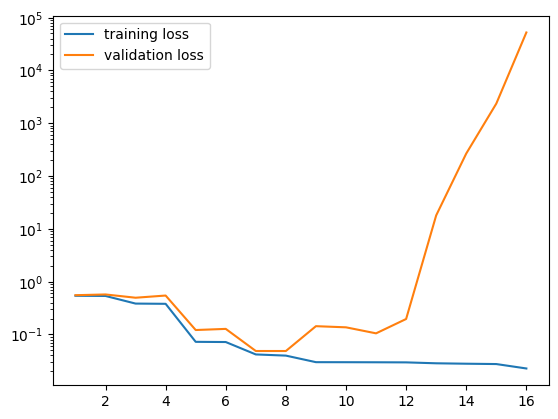

In [37]:
lst_p = np.arange(0, pmax + 1)

plt.plot(lst_p, losses_train, label = "training loss")
plt.plot(lst_p, losses_valid, label = "validation loss")
plt.legend()
plt.yscale("log")

(With the seed of the RNG set to 1234)

The training loss decreases, which shows that the more features are available, the better is the model on the training data. Additionally, the model is not very good for $p \leq 4$ (underfit).

For $p \leq 8$, the training and the validation loss are close, which shows that there is no overfitting problem (the model generalizes well).

However, after decreasing for $p \leq 8$, the validation loss increases and even explodes ($p \geq 13$). It illustrates the problem of overfitting: despite a small training loss, the validation loss is very large.

**Question 8: computation of the test loss**

We select the model with the best validation loss (polynomial regression with $p = 8$). Compute the test loss and plot the regression curve.

0.03967842176659077
0.06940198361113616


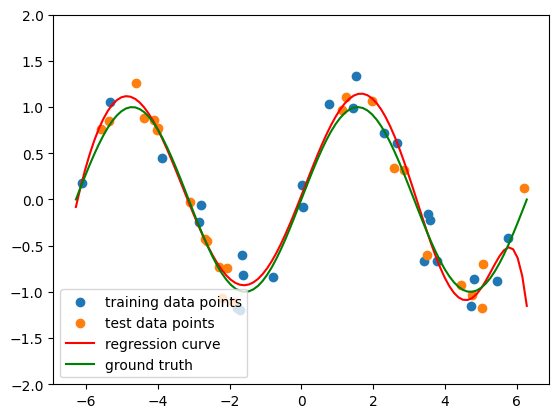

In [38]:
p = 8    # degree of the polynomial features with the best validation loss

pipeline.set_params(PolynomialFeatures__degree = p)
pipeline.fit(x_train, y_train)

loss_train = compute_loss(pipeline, x_train, y_train)
loss_test = compute_loss(pipeline, x_test, y_test)

print(loss_train)
print(loss_test)

npoints = 100
reg_x = np.linspace(xmin, xmax, npoints)

reg_y = pipeline.predict(reg_x)

plt.scatter(x_train, y_train, label = "training data points")
plt.scatter(x_test, y_test, label = "test data points")
plt.plot(reg_x, reg_y, c = "red", label = "regression curve")
plt.plot(reg_x, np.sin(reg_x), c = "green", label = "ground truth")
plt.ylim(-2, 2)
plt.legend()
plt.show()

# Principal Components Analysis

The goal of this small section is to propose to apply the Principal Components Analysis (PCA) on a custom dataset, by using sklearn and the polars (pl) library.

**Question 1**

Load the dataset "EU_countries.csv" by using `pl.read_csv()` and print it.

In [40]:
import polars as pl

df = pl.read_csv("EU_countries.csv")
df

,farm labour force,social protection expenditure,index of industrial production,gdp
str,f64,f64,f64,f64
"""AT""",0.011389,14892.78,21.359223,0.045366
"""BE""",0.00479,13153.31,36.425648,0.04397
"""BG""",0.036943,1952.12,14.155251,0.010274
"""CY""",0.020915,6174.57,37.362637,0.027821
"""CZ""",0.00984,4958.73,16.27907,0.022702
…,…,…,…,…
"""PT""",0.030474,5594.92,-0.990099,0.02098
"""RO""",0.085416,2102.37,10.987791,0.012583
"""SE""",0.00539,14451.86,17.647059,0.052097


**Question 2**

Remove the first column from the data table by using the `drop` method. 

Note: the label of this column is "".

In [41]:
df = df.drop("")
df

farm labour force,social protection expenditure,index of industrial production,gdp
f64,f64,f64,f64
0.011389,14892.78,21.359223,0.045366
0.00479,13153.31,36.425648,0.04397
0.036943,1952.12,14.155251,0.010274
0.020915,6174.57,37.362637,0.027821
0.00984,4958.73,16.27907,0.022702
…,…,…,…
0.030474,5594.92,-0.990099,0.02098
0.085416,2102.37,10.987791,0.012583
0.00539,14451.86,17.647059,0.052097


**Question 3**

Perform a PCA with dimension 2 on the dataset and plot the dataset projected on the space spanned by the first two principal components. Print the first two eigenvalues and eigenvectors.

Note: one can use the method `to_numpy()` to transform a `pl.DataFrame` into a `np.array`.

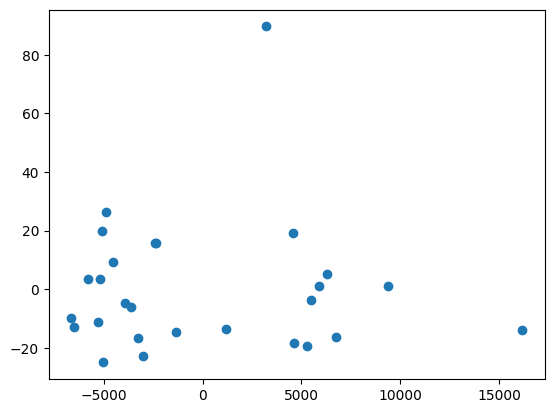

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
data_reduced = pca.fit_transform(df.to_numpy())
plt.scatter(data_reduced[:,0], data_reduced[:,1])

In [43]:
print("Eigenvalues:", pca.singular_values_)
print("Eigenvectors:", pca.components_)

Eigenvalues: [30182.89591992   116.48645948]
Eigenvectors: [[-2.09234309e-06  9.99999819e-01 -6.01372675e-04  3.54651699e-06]
 [ 1.72480769e-04  6.01371960e-04  9.99999761e-01  2.93749318e-04]]


**Question 4**

Now, perform a PCA after normalizing the dataset and plot the result. Normalization can be done by using `sklearn.preprocessing.StandardScaler`. Compare the plot to the preceding one. Are they the same?

Note: one can use the `fit_transform` method of `Pipeline` to return the processed data.

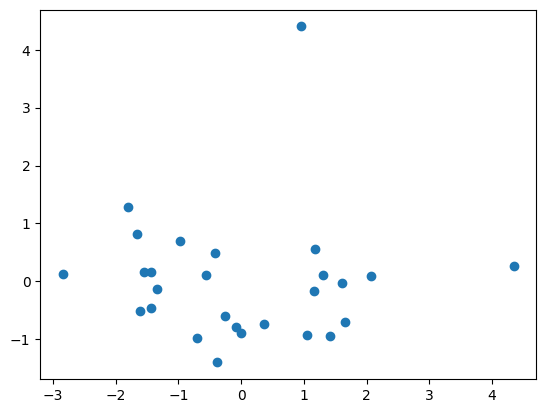

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pca = PCA(n_components = 2)

pipeline = Pipeline([("Scaler", scaler),
                     ("PCA", pca)])

data_reduced = pipeline.fit_transform(df.to_numpy())
plt.scatter(data_reduced[:,0], data_reduced[:,1])

The plot is different: the PCA is not invariant invariant by data translation and scaling. Usually, we normalize the dataset before performing the PCA in order to make sure that each of the initial features has the same weight in the PCA.